In [1]:
# Importamos Pandas y NumPy para manejar nuestra base de datos.
import pandas as pd
import numpy as np

# Importamos Matplotlib para crear visualizaciones.
import matplotlib.pyplot as plt

# Importamos utilidades de validación y muestreo.
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

# Importamos el clasificador SVM.
from sklearn.svm import SVC

# Importamos métricas para evaluar el desempeño del modelo.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Definimos la ruta y cargamos el dataset original
ruta = "us_congestion_2016_2022_sample_2m.csv"
df_completo = pd.read_csv(ruta)

# Seleccionamos las características (Features) y la etiqueta (Target)
# Usaremos Ubicación, Retraso y Clima para predecir la Severidad
columnas_X = ['Start_Lng', 'Start_Lat', 'DelayFromTypicalTraffic(mins)', 'Temperature(F)']
columna_y = 'Severity'

df_svm = df_completo[columnas_X + [columna_y]].dropna()

# Extraemos una muestra ESTRATIFICADA de 20,000 registros para no colapsar la PC
# 'stratify' asegura que mantengamos la misma proporción de Severidad 1, 2, 3 y 4 que en el dataset original
df_muestra = resample(df_svm, n_samples=100000, random_state=42, stratify=df_svm[columna_y])

X_raw = df_muestra[columnas_X]
y = df_muestra[columna_y].values

# ESCALAMOS LOS DATOS (Paso obligatorio para SVM)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Shape de X (Variables predictoras escaladas):", X.shape)
print("Shape de y (Etiquetas de Severidad):", y.shape)
print("Distribución de clases (Severidad):\n", df_muestra[columna_y].value_counts())

Shape de X (Variables predictoras escaladas): (100000, 4)
Shape de y (Etiquetas de Severidad): (100000,)
Distribución de clases (Severidad):
 Severity
1    46699
2    26181
0    24311
3     2809
Name: count, dtype: int64


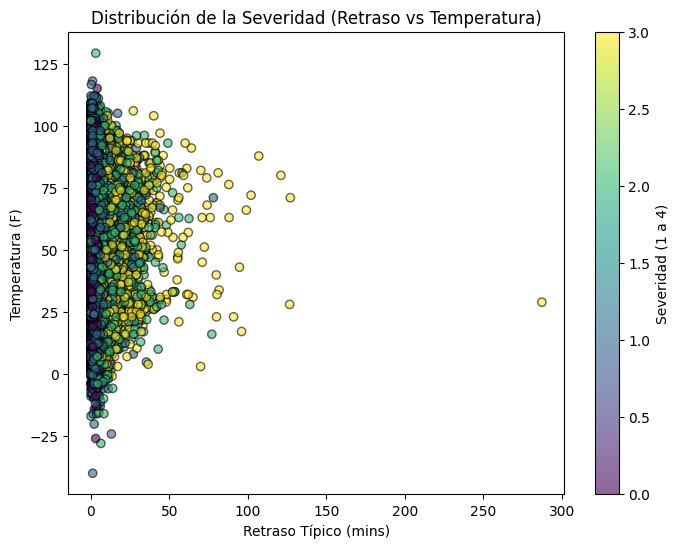

In [3]:
# Seleccionamos Retraso (índice 2) y Temperatura (índice 3) para la gráfica
# Usamos las variables sin escalar (X_raw) solo para que la gráfica sea fácil de leer
X_vis = X_raw.iloc[:, [2, 3]].values 

_, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_vis[:, 0],        # Retraso en minutos
    X_vis[:, 1],        # Temperatura en F
    c=y,                # Color según Severidad
    cmap='viridis',     # Paleta de colores
    alpha=0.6,
    edgecolors='k'
)

ax.set_title("Distribución de la Severidad (Retraso vs Temperatura)")
ax.set_xlabel("Retraso Típico (mins)")
ax.set_ylabel("Temperatura (F)")

# Leyenda para la Severidad
plt.colorbar(scatter, label='Severidad (1 a 4)')
plt.show()

In [4]:
# Dividimos los datos: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Variables de entrada ESCALADAS
    y,                  # Etiquetas de Severidad
    test_size=0.2,      # 20% para prueba
    random_state=42,    
    stratify=y          # Mantiene la proporción de Severidad en ambos sets
)

print("Shape de X_train (80%):", X_train.shape)
print("Shape de X_test (20%):", X_test.shape)

Shape de X_train (80%): (80000, 4)
Shape de X_test (20%): (20000, 4)


In [5]:
# Creamos un modelo SVM con kernel lineal.
svm_model = SVC(
    kernel="linear",    # Buscamos separaciones rectas
    C=1.0,              # Regularización estándar
    random_state=42
)

print("Entrenando modelo SVM Lineal... por favor espera.")
# Entrenamos el modelo
svm_model.fit(X_train, y_train)

print("¡Modelo SVM lineal entrenado correctamente!")

Entrenando modelo SVM Lineal... por favor espera.
¡Modelo SVM lineal entrenado correctamente!


In [6]:
# Predecimos la severidad en el conjunto de prueba.
y_pred = svm_model.predict(X_test)

# Calculamos métricas
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print(f"Accuracy Global: {acc * 100:.2f}%\n")
print("Matriz de confusión:")
print(cm)
print("\nReporte de clasificación:")
print(report)

Accuracy Global: 49.57%

Matriz de confusión:
[[   0 4860    2    0]
 [   0 8625  715    0]
 [   0 3947 1289    0]
 [   0  151  411    0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4862
           1       0.49      0.92      0.64      9340
           2       0.53      0.25      0.34      5236
           3       0.00      0.00      0.00       562

    accuracy                           0.50     20000
   macro avg       0.26      0.29      0.24     20000
weighted avg       0.37      0.50      0.39     20000



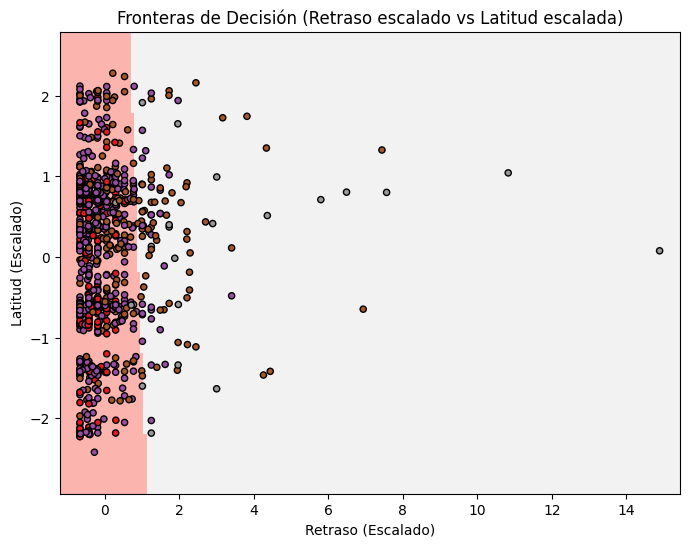

In [7]:
# Tomamos solo Retraso (idx 2) y Latitud (idx 1) escalados, y solo 1000 puntos para que grafique rápido
X_vis_scaled = X_train[:1000, [2, 1]] 
y_vis = y_train[:1000]

# Entrenamos un SVM lineal en 2D
svm_vis = SVC(kernel="linear", C=1.0, random_state=42)
svm_vis.fit(X_vis_scaled, y_vis)

# Malla para graficar
offset = 0.5
x_min, x_max = X_vis_scaled[:, 0].min() - offset, X_vis_scaled[:, 0].max() + offset
y_min, y_max = X_vis_scaled[:, 1].min() - offset, X_vis_scaled[:, 1].max() + offset
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Predecimos sobre la malla
pred_grid = svm_vis.predict(np.c_[x_grid.ravel(), y_grid.ravel()]).reshape(x_grid.shape)

_, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(x_grid, y_grid, pred_grid, cmap="Pastel1", shading="auto")
ax.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, cmap="Set1", edgecolors="k", s=20)

ax.set_title("Fronteras de Decisión (Retraso escalado vs Latitud escalada)")
ax.set_xlabel("Retraso (Escalado)")
ax.set_ylabel("Latitud (Escalado)")
plt.show()

In [8]:
# [Longitud, Latitud, Retraso(mins), Temperatura(F)]
# Simulamos un evento en Florida (-80.19, 25.76) con mucho retraso (60 min) y calor (85 F)
nuevo_evento = np.array([[-80.19, 25.76, 60.0, 85.0]])

# CRÍTICO: Escalar el nuevo evento con el mismo scaler
nuevo_evento_escalado = scaler.transform(nuevo_evento)

# Predecir
pred_nueva = svm_model.predict(nuevo_evento_escalado)[0]

print("Nuevo evento (Lng, Lat, Retraso, Temp):", nuevo_evento[0])
print(f"Severidad predicha por el SVM Lineal: Clase {pred_nueva}")

Nuevo evento (Lng, Lat, Retraso, Temp): [-80.19  25.76  60.    85.  ]
Severidad predicha por el SVM Lineal: Clase 2


c:\Users\USUARIO\Documents\Semestre9\ML\MachineLearning\Week_4_5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
